In [65]:
# imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [66]:
# import data
df = pd.read_csv('play_data.csv')
df = df.drop(columns = ['Unnamed: 0'])
df.columns

Index(['play_id', 'half_seconds_remaining', 'down', 'goal_to_go', 'ydstogo',
       'yardline_100', 'play_type', 'posteam_score', 'defteam_score', 'run'],
      dtype='object')

In [67]:
# preview data
df

,play_id,half_seconds_remaining,down,goal_to_go,ydstogo,yardline_100,play_type,posteam_score,defteam_score,run
0,63.0,1796.0,1.0,0,10.0,78.0,run,0.0,0.0,1
1,85.0,1758.0,2.0,0,7.0,75.0,pass,0.0,0.0,0
2,115.0,1720.0,1.0,0,10.0,64.0,pass,0.0,0.0,0
3,135.0,1677.0,2.0,0,21.0,75.0,run,0.0,0.0,1
4,166.0,1634.0,3.0,0,23.0,77.0,run,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...
4685,4510.0,377.0,2.0,0,6.0,74.0,pass,17.0,17.0,0
4686,4570.0,321.0,1.0,0,10.0,47.0,run,17.0,17.0,1
4687,4632.0,298.0,2.0,0,6.0,43.0,pass,17.0,17.0,0
4688,4655.0,294.0,3.0,0,6.0,43.0,pass,17.0,17.0,0


In [68]:
# setup variables
X = df.drop(columns=['run', 'play_type', 'play_id'])
y = df['run']

In [69]:
# breakup training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
# Set max_depth to control tree complexity 
model = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [74]:
# Predict outcomes on unseen test data
y_pred = model.predict(X_test)

# Output accuracy and classification metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n ", classification_report(y_test, y_pred))

Accuracy: 0.6076759061833689

Classification Report:
                precision    recall  f1-score   support

           0       0.59      0.98      0.74       535
           1       0.81      0.11      0.20       403

    accuracy                           0.61       938
   macro avg       0.70      0.55      0.47       938
weighted avg       0.69      0.61      0.51       938



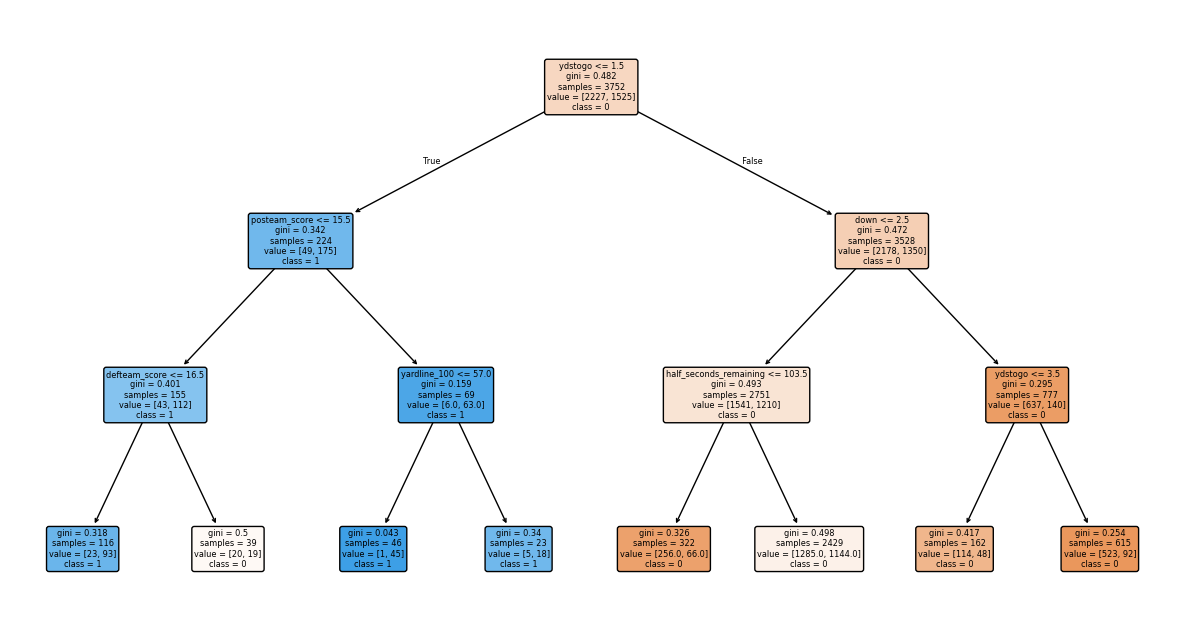

In [72]:
plt.figure(figsize=(15, 8))
plot_tree(
    model, 
    feature_names=X.columns, 
    class_names=[str(c) for c in model.classes_], 
    filled=True, 
    rounded=True
)
plt.show()